In [24]:
# %pip install nbconvert

from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from src.eda import figure, resume_univarie, profil_par_rayon

### 0. Données

In [25]:
# Ce nettoyage sera remplacé par celui du TP 9:

CSV_SOURCE = '../wip/echantillon_france.csv'

RAYON = "pnns_groups_1"
NUTRIMENTS = [
    "energy-kcal_100g", "fat_100g", "saturated-fat_100g", "carbohydrates_100g",
    "sugars_100g", "fiber_100g", "proteins_100g", "salt_100g", "sodium_100g",
    "fruits-vegetables-legumes_100g",
]
NUTRIMENTS_CLES = [
    "energy-kcal_100g", "fat_100g", "saturated-fat_100g", "carbohydrates_100g",
    "sugars_100g", "proteins_100g", "salt_100g",
]

def charger_propre() -> tuple[pd.DataFrame, dict[str, int]]:
    """Échantillon nettoyé a minima + compte rendu des lignes écartées."""
    df = pd.read_csv(CSV_SOURCE, dtype={"code": "string"}, low_memory=False)
    cr = {"lignes_entree": len(df)}
    d = df.drop_duplicates(subset="code", keep="first")
    cr["doublons_codes"] = len(df) - len(d)
    ok = pd.Series(True, index=d.index)
    for c in NUTRIMENTS:
        if c != "energy-kcal_100g":
            ok &= d[c].isna() | d[c].between(0, 100)
    cr["hors_bornes"] = int((~ok).sum())
    d = d[ok]
    ok_e = d["energy-kcal_100g"].isna() | d["energy-kcal_100g"].between(0, 900)
    cr["energie_implausible"] = int((~ok_e).sum())
    d = d[ok_e]
    connu = d[RAYON].notna() & (d[RAYON] != "unknown")
    cr["rayon_inconnu"] = int((~connu).sum())
    d = d[connu].reset_index(drop=True)
    cr["lignes_sortie"] = len(d)
    return d, cr

In [26]:
df, cr = charger_propre()
print(cr)

{'lignes_entree': 8689, 'doublons_codes': 26, 'hors_bornes': 136, 'energie_implausible': 127, 'rayon_inconnu': 1726, 'lignes_sortie': 6674}


### 1. Distributions par rayon

#### question :
Comment les nutriments (sucre, sel, calories) et les notes Nutri-Score se répartissent-ils selon les différents rayons alimentaires ?

#### méthode : 
• Nettoyage : suppression des erreurs et des doublons.  
• Analyse des formes : Utilisation d'histogrammes et de boîtes à moustaches (boxplots) pour voir comment les données se regroupent ou s'étalent.  
• Calculs clés : Mesure des moyennes, des médianes (pour éviter l'effet des valeurs extrêmes) et du V de Cramér (pour mesurer le lien entre un rayon et sa note Nutri-Score).  

#### résultat :
• Des écarts géants : Le sucre et le sel ont des distributions très déséquilibrées. Quelques produits ultra-transformés tirent les moyennes vers le haut.  
• Des rayons spécialisés : Le sucre explose dans les Sugary snacks (médiane de 38 g/100g) et le sel domine dans le rayon Fish Meat Eggs (médiane de 1,5 g/100g).  
• Un lien direct : Le rayon détermine fortement la note. Le V de Cramér de 0,34 confirme que les mauvaises notes (D et E) s'entassent massivement sur les collations sucrées (92,7 %) et salées (60,3 %).  
• Une valeur de V de Cramér ~0,34 indique que le rayon et le Nutri-Score ne sont pas indépendants  
• Connaître le rayon d'un produit donne une indication sur sa note Nutri-Score  

#### trois lignes :
• Le rayon d'un produit est le meilleur indicateur pour deviner sa qualité nutritionnelle.  
• Les moyennes globales sont trompeuses ; il faut utiliser la médiane pour analyser correctement ce marché.  
• Les produits "plaisir" et la charcuterie/viande concentrent l'essentiel des notes critiques.

#### décision :
Pour la suite de l'analyse, il sera indispensable de séparer les produits par rayon plutôt que de les étudier globalement.

,n,manquants,moyenne,mediane,ecart_type,IQR,MAD,CV,asymetrie,aplatissement,p05,p95,min,max
sugars_100g,5546.0,1128.0,12.938774,3.0,19.789862,15.6000,3.00,1.529501,1.887813,2.938075,0.0,57.5000,0.0,100.0
salt_100g,5418.0,1256.0,1.065075,0.5,2.372993,1.2498,0.49,2.228005,11.129568,240.781448,0.0,3.6745,0.0,77.5
energy-kcal_100g,5599.0,1075.0,275.073776,254.0,192.814297,286.0000,143.00,0.700955,0.709334,0.252448,23.0,597.0000,0.0,900.0


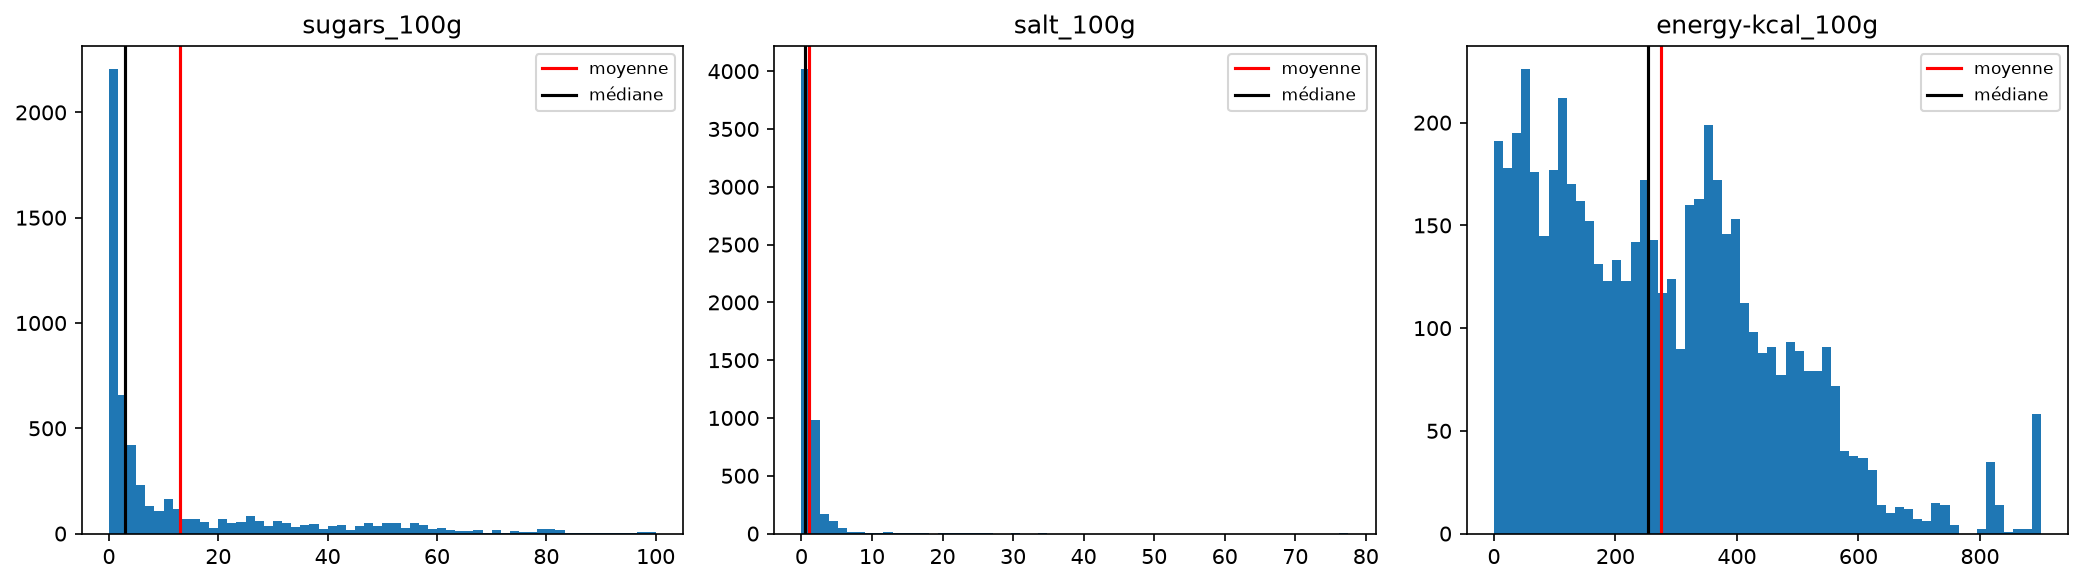

--- LISTE DES RAYONS ÉCARTÉS (Effectif < 30) ---
Aucun rayon écarté.


,,effectif,moyenne,mediane,q1,q3
nutriment,rayon,,,,,
sugars_100g,Alcoholic beverages,43,6.355442,0.140000,0.000000,5.50000
salt_100g,Alcoholic beverages,42,0.219929,0.000000,0.000000,0.01000
energy-kcal_100g,Alcoholic beverages,46,97.338735,49.904545,23.750000,78.00000
sugars_100g,Baby foods,50,10.300800,5.600000,2.325000,10.50000
salt_100g,Baby foods,47,0.135069,0.080000,0.050400,0.21168
energy-kcal_100g,Baby foods,50,141.268400,67.000000,59.250000,88.75000
sugars_100g,Beverages,452,10.138185,6.100000,0.145000,10.47000
salt_100g,Beverages,442,0.318692,0.010000,0.000000,0.05000
energy-kcal_100g,Beverages,468,71.398316,37.000000,5.000000,54.00000


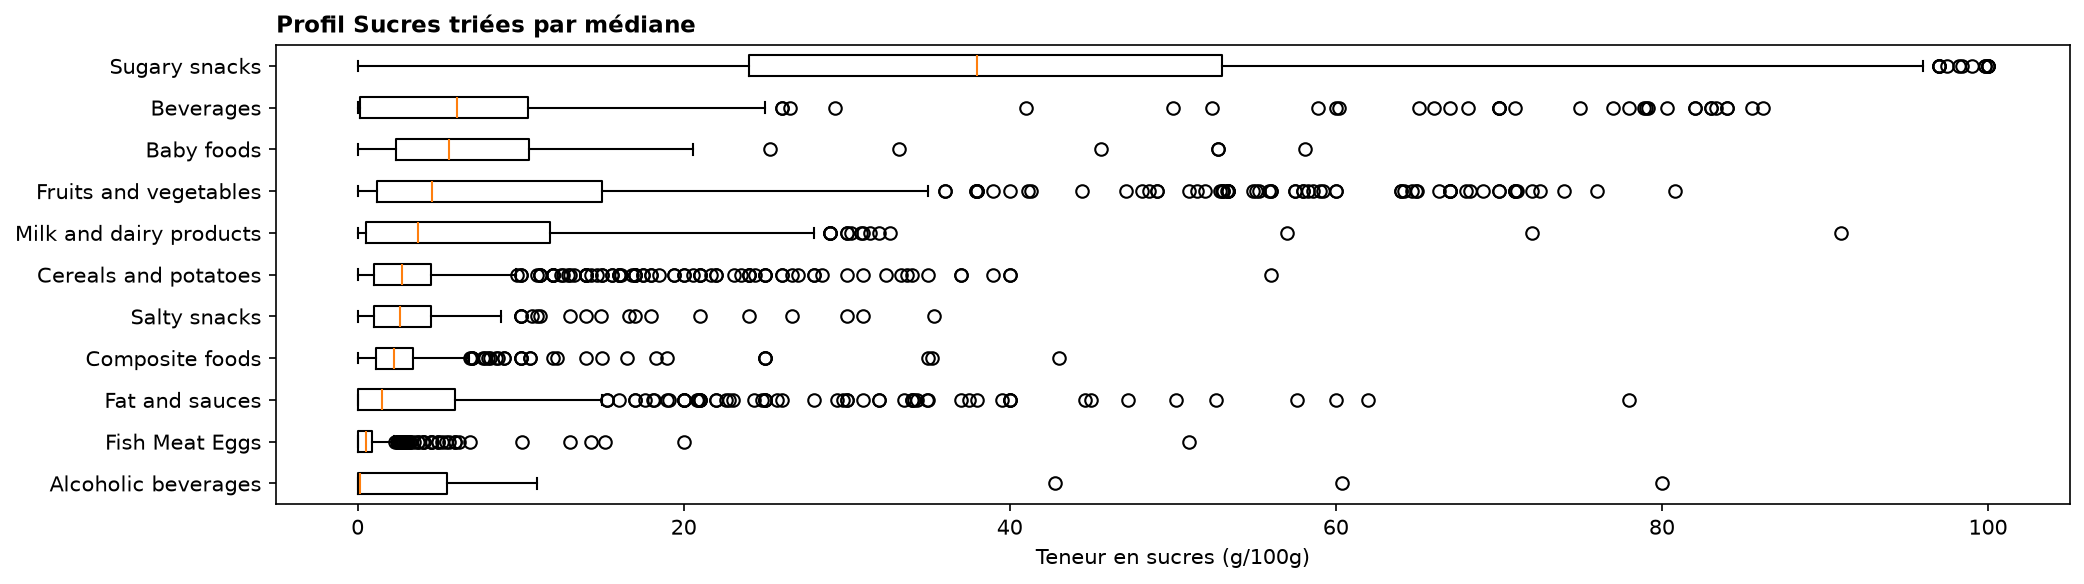

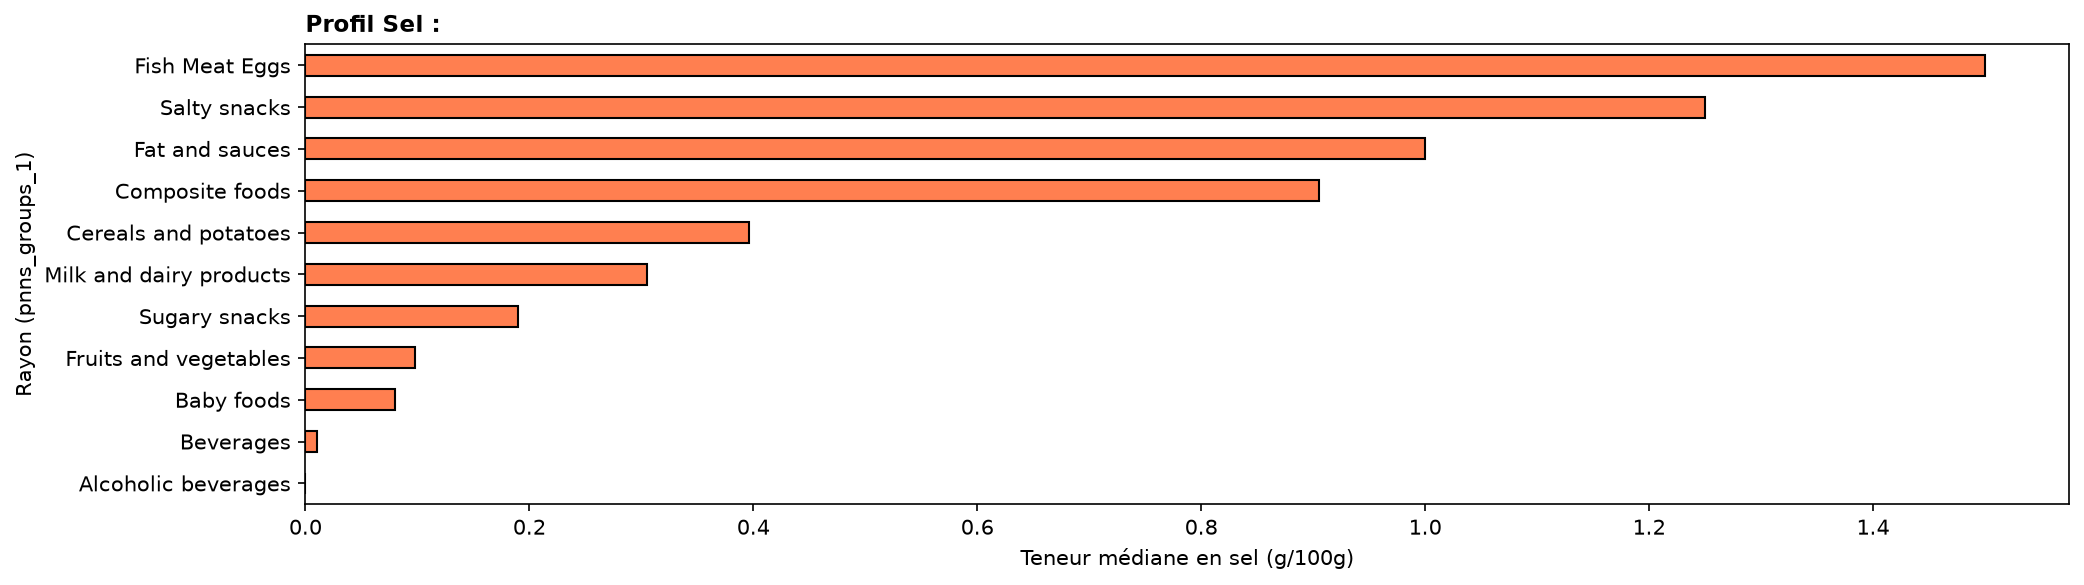

--- PROFIL LIGNE (%) PAR RAYON ---
nutriscore_grade            a     b     c     d     e
pnns_groups_1                                        
Alcoholic beverages       0.0  50.0   0.0   0.0  50.0
Beverages                 6.9  24.4  27.6  17.2  23.9
Cereals and potatoes     33.3  19.8  26.3  16.8   3.9
Composite foods           8.4  15.9  48.3  23.7   3.7
Fat and sauces            6.4  20.6  20.4  16.0  36.6
Fish Meat Eggs           20.0   9.2  13.3  27.4  30.2
Fruits and vegetables    50.3  14.2  16.3  12.5   6.7
Milk and dairy products   5.2   7.2  30.6  45.8  11.2
Salty snacks              9.8   9.8  20.0  29.5  30.8
Sugary snacks             0.9   0.8   5.6  26.6  66.1

--- PART DES GRADES CRITIQUES D + E PAR RAYON ---
• Alcoholic beverages : 50.0%
• Beverages : 41.1%
• Cereals and potatoes : 20.7%
• Composite foods : 27.4%
• Fat and sauces : 52.6%
• Fish Meat Eggs : 57.5%
• Fruits and vegetables : 19.2%
• Milk and dairy products : 57.0%
• Salty snacks : 60.3%
• Sugary snacks : 92

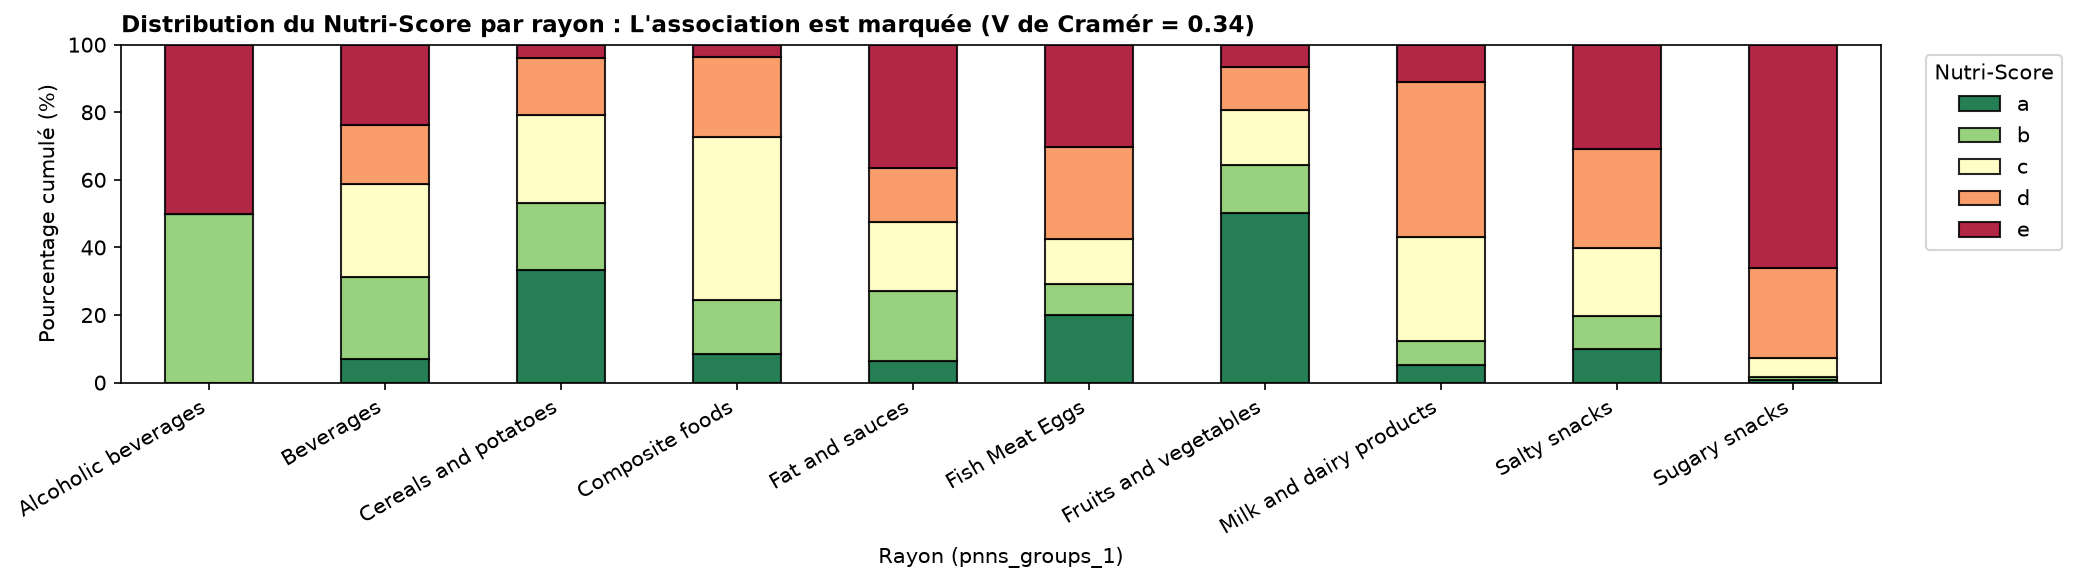

In [27]:
NUTRIMENTS_CIBLE = ["sugars_100g", "salt_100g", "energy-kcal_100g"]

tab = pd.DataFrame({c: resume_univarie(df[c]) for c in NUTRIMENTS_CIBLE})
display(tab.T)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for j, c in enumerate(NUTRIMENTS_CIBLE):
    x = df[c].dropna()
    axes[j].hist(x, bins=60)
    axes[j].axvline(x.mean(), color="red", label="moyenne")
    axes[j].axvline(x.median(), color="black", label="médiane")
    axes[j].set_title(c)
    axes[j].legend(fontsize=8)
fig.tight_layout()

figure(fig, f"dist_{c}")

##########################

tab = profil_par_rayon(df, NUTRIMENTS_CIBLE)
display(tab)

if "sugars_100g" in NUTRIMENTS_CIBLE:
    # Tri basé sur la médiane des sucres
    ordre_sucres = (
        df.groupby(RAYON, observed=True)["sugars_100g"]
            .median()
            .sort_values()
            .index
    )

    fig_box, ax_box = plt.subplots(figsize=(14, 4))
    donnees_boites = [
        df[df[RAYON] == r]["sugars_100g"].dropna()
        for r in ordre_sucres
    ]

    ax_box.boxplot(donnees_boites, orientation="horizontal", tick_labels=ordre_sucres)

    ax_box.set_title(
        "Profil Sucres triées par médiane",
        fontsize=11,
        fontweight="bold",
        loc="left",
    )
    ax_box.set_xlabel("Teneur en sucres (g/100g)")
    fig_box.tight_layout()

    figure(fig_box, "profil_mediane_sucres")

##########################

if "salt_100g" in NUTRIMENTS_CIBLE:
    # Calcul et tri des médianes de sel
    sel_medians = (
        df.groupby(RAYON)["salt_100g"].median().sort_values()
    )

    fig_bar, ax_bar = plt.subplots(figsize=(14, 4))
    sel_medians.plot(kind="barh", ax=ax_bar, color="coral", edgecolor="black")

    ax_bar.set_title(
        "Profil Sel :",
        fontsize=11,
        fontweight="bold",
        loc="left",
    )
    ax_bar.set_xlabel("Teneur médiane en sel (g/100g)")
    ax_bar.set_ylabel("Rayon (pnns_groups_1)")
    fig_bar.tight_layout()

    figure(fig_bar, "profil_barres_sel")

##########################

# Filtrage sur les notes valides en minuscules 'abcde' et suppression des NaN
g = df[df["nutriscore_grade"].isin(list("abcde")) & df[RAYON].notna()].copy()

# Tableau de contingence normalisé par ligne (en %)
ct = pd.crosstab(g[RAYON], g["nutriscore_grade"], normalize="index") * 100

print("--- PROFIL LIGNE (%) PAR RAYON ---")
print(ct.round(1).to_string())

# Calcul et affichage de la part cumulée critique D + E
part_de = ct[["d", "e"]].sum(axis=1).round(1).to_dict()
print("\n--- PART DES GRADES CRITIQUES D + E PAR RAYON ---")
for rayon, valeur in part_de.items():
    print(f"• {rayon} : {valeur}%")
    
# Calcul du V de Cramér via la table des effectifs réels (non normalisée)
ct_counts = pd.crosstab(g[RAYON], g["nutriscore_grade"])
chi2, p, dof, expected = stats.chi2_contingency(ct_counts)
n = ct_counts.sum().sum()
min_dim = min(ct_counts.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0.0

print(f"\nStatistique : V de Cramér = {v_cramer:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))

# Vert pour A, Jaune pour C, Rouge pour E
ct.plot(kind="bar", stacked=True, ax=ax, cmap="RdYlGn_r", edgecolor="black", alpha=0.85)

ax.set_title(
    f"Distribution du Nutri-Score par rayon : L'association est marquée (V de Cramér = {v_cramer:.2f})", 
    fontsize=11, 
    fontweight="bold", 
    loc="left"
)
ax.set_xlabel("Rayon (pnns_groups_1)")
ax.set_ylabel("Pourcentage cumulé (%)")
ax.set_ylim(0, 100)
ax.legend(title="Nutri-Score", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()

figure(fig, "croisement_rayon_grade")

### 2. Complétude et qualité

#### question :

#### méthode : 

#### résultat :

#### trois lignes :

#### décision :

### 3. Corrélations

#### question :

#### méthode : 

#### résultat :

#### trois lignes :

#### décision :

### 4. Extrêmes restants

#### question :

#### méthode : 

#### résultat :

#### trois lignes :

#### décision :

### 5. Hypothèses et registre

#### question :

#### méthode : 

#### résultat :

#### trois lignes :

#### décision :

### 6. Synthèse

#### question :

#### méthode : 

#### résultat :

#### trois lignes :

#### décision :